# Optimization Fundamentals

This notebook builds the numerical optimization foundation used throughout optimal control.

The focus is not optimization theory itself, but understanding how an optimization problem is represented and solved computationally.

We will study three cases:

1. Unconstrained optimization
2. Equality-constrained optimization
3. Inequality-constrained optimization

For each problem, we will distinguish between:

- **decision variables**
- **objective function**
- **constraints**
- **design / tuning parameters**
- **solution algorithm**

JAX will be used for automatic differentiation, while the core optimization steps will be implemented explicitly.

## 1. Unconstrained Optimization

Consider the quadratic optimization problem

$$
\min_{z \in \mathbb{R}^2} f(z)
$$

with

$$
f(z) =
\frac{1}{2} z^\top Qz + b^\top z
$$

where

$$
Q =
\begin{bmatrix}
4 & 1 \\
1 & 2
\end{bmatrix},
\qquad
b =
\begin{bmatrix}
-1 \\
-2
\end{bmatrix}.
$$

### Problem components

- **Decision variable:** $z \in \mathbb{R}^2$
- **Objective:** $f(z)$
- **Constraints:** none
- **Optimization parameters:** initial guess and step size

The objective is deliberately simple so that we can focus on how the optimizer moves through the cost landscape.

In [3]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

print("JAX devices:", jax.devices())
print("Backend:", jax.default_backend())

jax.config.update("jax_enable_x64", True)

Q = jnp.array([
    [4.0,1.0],
    [1.0,2.0],
])

b = jnp.array([-1.0, -2.0])

def objective(z):
    return 0.5 * z @ Q @ z + b @ z

JAX devices: [CudaDevice(id=0)]
Backend: gpu


### Derivatives with JAX

Gradient-based optimization requires

$$
\nabla f(z).
$$

For the quadratic objective,

$$
\nabla f(z) = Qz + b.
$$

Instead of manually providing the derivative to the optimizer, we use JAX automatic differentiation.

In [4]:
grad_objective = jax.grad(objective)
hess_objective = jax.hessian(objective)

In [5]:
z_test = jnp.array([1.0, 1.0])

print("Objective:", objective(z_test))
print("Gradient:", grad_objective(z_test))
print("Hessian:\n", hess_objective(z_test))

Objective: 1.0
Gradient: [4. 1.]
Hessian:
 [[4. 1.]
 [1. 2.]]


### Gradient Descent

Starting from an initial guess $z_0$, gradient descent repeatedly moves in the direction opposite to the gradient:

$$
z_{k+1}=
z_k-\alpha \nabla f(z_k),
$$

where $\alpha > 0$ is the step size.

The gradient determines the direction of local increase of the objective, so $-\nabla f$ provides a descent direction.

In [6]:
def gradient_step(z, step_size):
    grad = grad_objective(z)
    return z - step_size * grad

### Gradient Solver

In [7]:
def gradient_descent(z0, step_size, num_steps):
    z = z0
    trajectory = [z]

    for _ in range(num_steps):
        z = gradient_step(z,step_size)
        trajectory.append(z)

    return z, jnp.stack(trajectory)

In [17]:
z0 = jnp.array([-4.0, 3.0])

z_star_gd, trajectory_gd = gradient_descent(
    z0=z0,
    step_size=0.1,
    num_steps=100,
)

print("Initial point:", z0)
print("Final point:", z_star_gd)
print("Final cost:", objective(z_star_gd))

Initial point: [-4.  3.]
Final point: [-4.10124514e-08  1.00000010e+00]
Final cost: -0.9999999999999909


In [18]:
z_star_exact = -jnp.linalg.solve(Q, b)

print("Exact optimum:", z_star_exact)
print("Gradient descent:", z_star_gd)

Exact optimum: [-0.  1.]
Gradient descent: [-4.10124514e-08  1.00000010e+00]


### Visualize

In [19]:
z1 = jnp.linspace(-3.0, 3.0, 200)
z2 = jnp.linspace(-1.0, 4.0, 200)

Z1, Z2 = jnp.meshgrid(z1, z2)

points = jnp.stack([Z1.ravel(), Z2.ravel()], axis=-1)
costs = jax.vmap(objective)(points).reshape(Z1.shape)

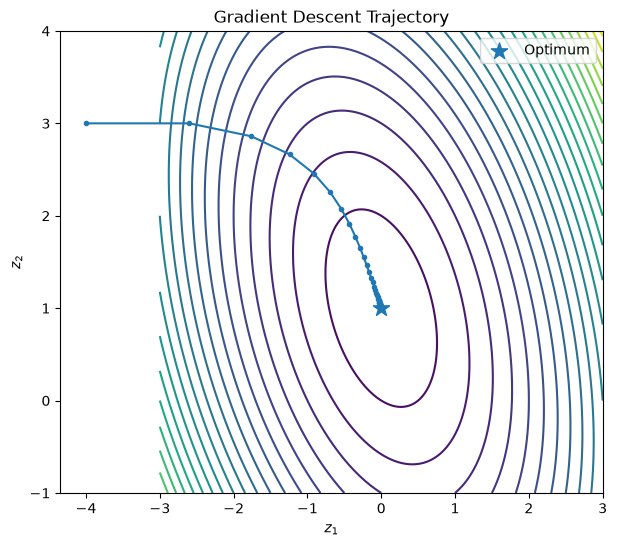

In [20]:
plt.figure(figsize=(7, 6))

plt.contour(Z1, Z2, costs, levels=25)

plt.plot(
    trajectory_gd[:, 0],
    trajectory_gd[:, 1],
    marker="o",
    markersize=3,
)

plt.scatter(
    z_star_exact[0],
    z_star_exact[1],
    marker="*",
    s=150,
    label="Optimum",
)

plt.xlabel("$z_1$")
plt.ylabel("$z_2$")
plt.title("Gradient Descent Trajectory")
plt.legend()
plt.show()

### Small experiment: step size

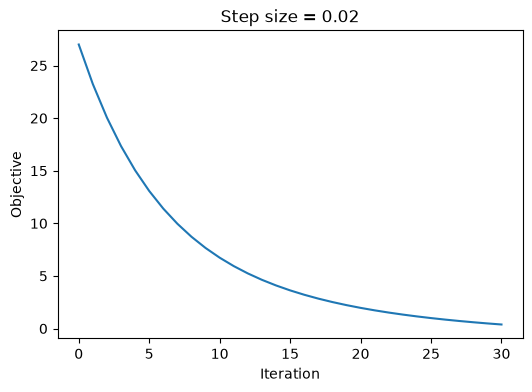

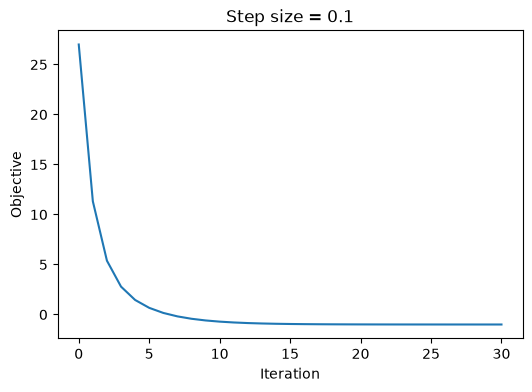

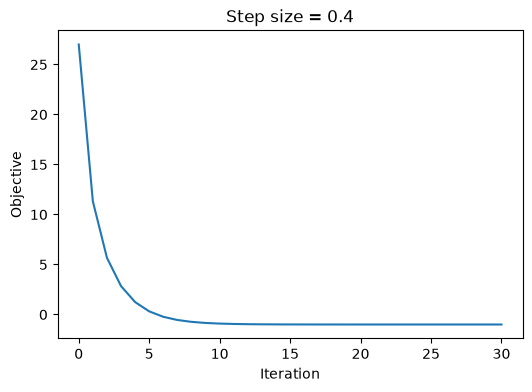

In [23]:
step_sizes = [0.02, 0.1, 0.4]

for step_size in step_sizes:
    _, trajectory = gradient_descent(
        z0=z0,
        step_size=step_size,
        num_steps=30,
    )

    costs = jax.vmap(objective)(trajectory)

    plt.figure(figsize=(6, 4))
    plt.plot(costs)
    plt.xlabel("Iteration")
    plt.ylabel("Objective")
    plt.title(f"Step size = {step_size}")
    plt.show()

### Newton's Method

Gradient descent uses first-order information.

Newton's method additionally uses the local curvature represented by the Hessian:

$$
z_{k+1}=
z_k-
\left[\nabla^2 f(z_k)\right]^{-1}
\nabla f(z_k).
$$

This allows the update direction to account for the shape of the objective rather than using only the gradient.

In [24]:
def newton_step(z):
    grad = grad_objective(z)
    hess = hess_objective(z)

    direction = jnp.linalg.solve(hess, grad)

    return z - direction

In [25]:
def newton_method(z0, num_steps):
    z = z0
    trajectory = [z]

    for _ in range(num_steps):
        z = newton_step(z)
        trajectory.append(z)

    return z, jnp.stack(trajectory)

In [26]:
z_star_newton, trajectory_newton = newton_method(
    z0=z0,
    num_steps=3,
)

print("Newton solution:", z_star_newton)
print("Exact solution:", z_star_exact)

Newton solution: [0. 1.]
Exact solution: [-0.  1.]


### Takeaway

An optimization problem separates the **problem definition** from the **algorithm used to solve it**.

For the same objective we used two algorithms:

- **Gradient descent**: uses first-order information
- **Newton's method**: uses first- and second-order information

JAX provides the required derivatives, while the optimization update itself remains explicit.

The optimizer's behavior depends not only on the objective, but also on algorithmic choices such as the update direction and step size.

## 2. Equality-Constrained Optimization

Now consider an optimization problem in which the decision variable cannot move freely.

$$
\min_{z \in \mathbb{R}^2} f(z)
$$

subject to

$$
h(z)=0.
$$

We use the same quadratic objective,

$$
f(z)=\frac{1}{2}z^\top Qz+b^\top z,
$$

but impose the constraint

$$
z_1+z_2=1.
$$

The optimization problem is therefore

$$
\min_z f(z)
\qquad
\text{s.t.}
\qquad
z_1+z_2-1=0.
$$

The constraint defines the **feasible set**. The optimizer must now find the lowest-cost point that also lies on this set.

In [38]:
def equality_constraint(z):
    return z[0] + z[1] - 1.0

In [39]:
z1 = jnp.linspace(-3.0, 3.0, 200)
z2 = jnp.linspace(-2.0, 4.0, 200)

Z1, Z2 = jnp.meshgrid(z1, z2)

points = jnp.stack(
    [Z1.ravel(), Z2.ravel()],
    axis=-1,
)

cost_grid = jax.vmap(objective)(points).reshape(Z1.shape)

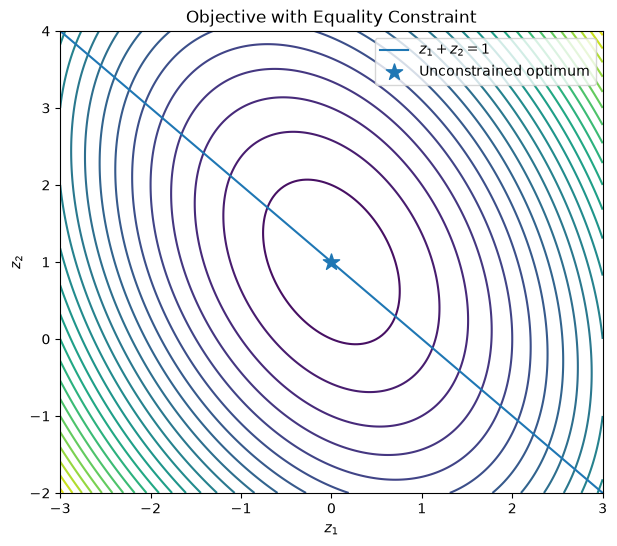

In [40]:
plt.figure(figsize=(7, 6))

plt.contour(Z1, Z2, cost_grid, levels=25)

constraint_z1 = jnp.linspace(-3.0, 3.0, 200)
constraint_z2 = 1.0 - constraint_z1

plt.plot(
    constraint_z1,
    constraint_z2,
    label=r"$z_1 + z_2 = 1$",
)

plt.scatter(
    z_star_exact[0],
    z_star_exact[1],
    marker="*",
    s=150,
    label="Unconstrained optimum",
)

plt.xlabel("$z_1$")
plt.ylabel("$z_2$")
plt.title("Objective with Equality Constraint")
plt.legend()
plt.show()

### Lagrangian

For an equality constraint

$$
h(z)=0,
$$

introduce a Lagrange multiplier \(\lambda\) and define

$$
\mathcal{L}(z,\lambda)=
f(z)+\lambda h(z).
$$

For our problem,

$$
\mathcal{L}(z,\lambda)=
\frac12z^\top Qz+b^\top z
+
\lambda(z_1+z_2-1).
$$

At a regular constrained optimum,

$$
\nabla_z \mathcal{L}(z^\star,\lambda^\star)=0,
$$

together with

$$
h(z^\star)=0.
$$

In [41]:
A = jnp.array([[1.0, 1.0]])
c = jnp.array([1.0])


KKT = jnp.block([
    [Q, A.T],
    [A, jnp.zeros((1, 1))],
])

rhs = jnp.concatenate([
    -b,
    c,
])

solution = jnp.linalg.solve(KKT, rhs)

z_star_eq = solution[:2]
lambda_star = solution[2]

print("Constrained optimum:", z_star_eq)
print("Lagrange multiplier:", lambda_star)
print("Constraint value:", equality_constraint(z_star_eq))
print("Cost:", objective(z_star_eq))

Constrained optimum: [0. 1.]
Lagrange multiplier: -7.28583859910259e-17
Constraint value: 0.0
Cost: -1.0


### Visualize

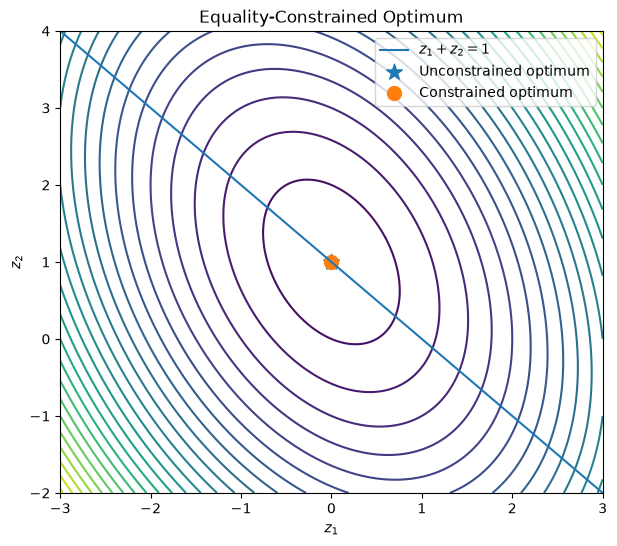

In [43]:
plt.figure(figsize=(7, 6))

plt.contour(Z1, Z2, cost_grid, levels=25)

plt.plot(
    constraint_z1,
    constraint_z2,
    label=r"$z_1 + z_2 = 1$",
)

plt.scatter(
    z_star_exact[0],
    z_star_exact[1],
    marker="*",
    s=140,
    label="Unconstrained optimum",
)

plt.scatter(
    z_star_eq[0],
    z_star_eq[1],
    marker="o",
    s=100,
    label="Constrained optimum",
)

plt.xlabel("$z_1$")
plt.ylabel("$z_2$")
plt.title("Equality-Constrained Optimum")
plt.legend()
plt.show()

In [45]:
grad_f_star = grad_objective(z_star_eq)
grad_h_star = jax.grad(equality_constraint)(z_star_eq)

print("Objective gradient:", grad_f_star)
print("Constraint gradient:", grad_h_star)
print("grad f + lambda grad h:",
      grad_f_star + lambda_star * grad_h_star)

Objective gradient: [0. 0.]
Constraint gradient: [1. 1.]
grad f + lambda grad h: [-7.2858386e-17 -7.2858386e-17]


### Takeaway

With an equality constraint, the optimum is no longer determined only by

$$
\nabla f(z)=0.
$$

It must satisfy both:

$$
\nabla_z\mathcal{L}(z,\lambda)=0
$$

and

$$
h(z)=0.
$$

For a quadratic objective with linear equality constraints, these conditions form a linear KKT system that can be solved directly.

The constrained solution may therefore differ from the unconstrained minimum because optimization is restricted to the feasible set.

## 3. Inequality-Constrained Optimization

Consider

$$
\min_{z \in \mathbb{R}^2} f(z)
$$

subject to

$$
g(z)\le 0.
$$

We again use the same quadratic objective,

$$
f(z)=\frac12 z^\top Qz+b^\top z,
$$

but impose

$$
z_1 \le 0.
$$

Equivalently,

$$
g(z)=z_1 \le 0.
$$

The key difference from an equality constraint is that the optimizer may lie either:

- inside the feasible region, where the constraint is inactive, or
- on the boundary, where the constraint is active.

In [46]:
def inequality_constraint(z):
    return z[0]

In [47]:
print("Unconstrained optimum:", z_star_exact)
print("Constraint value:", inequality_constraint(z_star_exact))

Unconstrained optimum: [-0.  1.]
Constraint value: -0.0


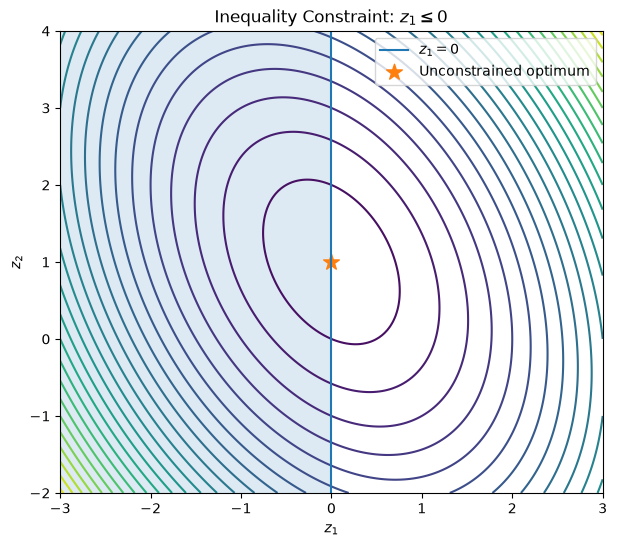

In [48]:
plt.figure(figsize=(7, 6))

plt.contour(Z1, Z2, cost_grid, levels=25)

plt.axvline(
    0.0,
    label=r"$z_1 = 0$",
)

plt.fill_betweenx(
    z2,
    z1.min(),
    0.0,
    alpha=0.15,
)

plt.scatter(
    z_star_exact[0],
    z_star_exact[1],
    marker="*",
    s=140,
    label="Unconstrained optimum",
)

plt.xlabel("$z_1$")
plt.ylabel("$z_2$")
plt.title("Inequality Constraint: $z_1 \\leq 0$")
plt.legend()
plt.show()

### KKT Conditions

For

$$
g(z)\le 0,
$$

define the Lagrangian

$$
\mathcal L(z,\mu)
=f(z)+\mu g(z).
$$

At a regular constrained optimum, the KKT conditions include

$$
\nabla_z \mathcal L(z^\star,\mu^\star)=0,
$$

$$
g(z^\star)\le 0,
$$

$$
\mu^\star \ge 0,
$$

and

$$
\mu^\star g(z^\star)=0.
$$

The last condition is called **complementary slackness**.

In [49]:
def boundary_objective(z2):
    z = jnp.array([0.0, z2])
    return objective(z)

grad_boundary_objective = jax.grad(boundary_objective)

z2_star = -b[1] / Q[1, 1]

z_star_ineq = jnp.array([0.0, z2_star])

print("Constrained optimum:", z_star_ineq)
print("Constraint value:", inequality_constraint(z_star_ineq))
print("Cost:", objective(z_star_ineq))

Constrained optimum: [0. 1.]
Constraint value: 0.0
Cost: -1.0


In [50]:
grad_f_ineq = grad_objective(z_star_ineq)
grad_g_ineq = jax.grad(inequality_constraint)(z_star_ineq)

mu_star = -grad_f_ineq[0] / grad_g_ineq[0]

print("grad f:", grad_f_ineq)
print("grad g:", grad_g_ineq)
print("mu:", mu_star)
print(
    "stationarity:",
    grad_f_ineq + mu_star * grad_g_ineq
)

grad f: [0. 0.]
grad g: [1. 0.]
mu: -0.0
stationarity: [0. 0.]


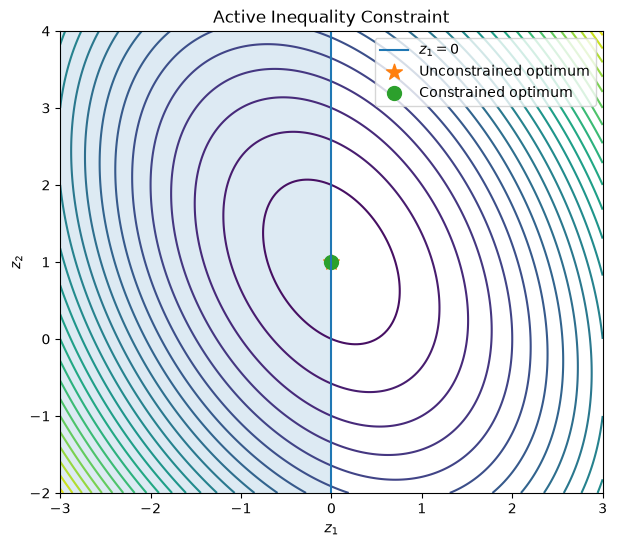

In [51]:
plt.figure(figsize=(7, 6))

plt.contour(Z1, Z2, cost_grid, levels=25)

plt.axvline(
    0.0,
    label=r"$z_1 = 0$",
)

plt.fill_betweenx(
    z2,
    z1.min(),
    0.0,
    alpha=0.15,
)

plt.scatter(
    z_star_exact[0],
    z_star_exact[1],
    marker="*",
    s=140,
    label="Unconstrained optimum",
)

plt.scatter(
    z_star_ineq[0],
    z_star_ineq[1],
    marker="o",
    s=100,
    label="Constrained optimum",
)

plt.xlabel("$z_1$")
plt.ylabel("$z_2$")
plt.title("Active Inequality Constraint")
plt.legend()
plt.show()

### Takeaway

Inequality constraints introduce the concept of **active constraints**.

If a constraint is inactive,

$$
g(z^\star)<0,
$$

it does not affect the optimum.

If it is active,

$$
g(z^\star)=0,
$$

it behaves locally like an equality constraint.

The KKT conditions combine:

- stationarity,
- primal feasibility,
- dual feasibility,
- complementary slackness.

These conditions will later reappear naturally in constrained control problems such as actuator limits, state bounds, road boundaries, and safety constraints.